In [111]:
import pandas as pd

invoice = pd.read_csv('fct_invoice.csv')
customers_list = pd.read_json('dim_customer.json')

In [112]:
#EASY LEVEL
#QUESTION 1: How many unique customers are in the dataset?

#Count number of unique customer IDs
answer = pd.unique(customers_list['id'])
answer = len(answer)

print('EASY - QUESTION 1')
print('There are ' + str(answer) + ' unique customers.')

EASY - QUESTION 1
There are 5191 unique customers.


In [113]:
#EASY LEVEL
#QUESTION 2: What are the different categories of products available? How many unique categories are there?

#Enumerate and count number of unique categories
answer1 = pd.unique(invoice['category'])
answer2 = len(answer1)

print('EASY - QUESTION 2')
print('There are ' + str(answer2) + ' unique categories, namely:')
print(answer1)

EASY - QUESTION 2
There are 8 unique categories, namely:
['Clothing' 'Shoes' 'Books' 'Cosmetics' 'Food & Beverage' 'Toys'
 'Technology' 'Souvenir']


In [114]:
#EASY LEVEL
#QUESTION 3: Which payment method is the most popular? How many times was it used?

print('EASY - QUESTION 3')

#Identify which payment method has the most instances
method = invoice['payment_method'].value_counts().idxmax()
print('Most popular method: ' + method)

#Identify the highest number of instances in the payment_method column
count = invoice['payment_method'].value_counts().max()
print('Used ' + str(count) + ' times')

EASY - QUESTION 3
Most popular method: Cash
Used 44447 times


In [115]:
#MEDIUM LEVEL
#QUESTION 1: What are the three most popular categories, by total sales?
#Note: In this code, sale = quantity*price

#Add sales column
invoice['sales'] = invoice['quantity'] * invoice['price']

#Filter table then group by category
sales = invoice[['category','sales']]
summary = sales.groupby('category').sum()

#Identify top 3 highest sales per category
top = summary.nlargest(3,'sales')

print('MEDIUM - QUESTION 1')
print('3 most popular categories by total sales:')
print(top)

MEDIUM - QUESTION 1
3 most popular categories by total sales:
                   sales
category                
Clothing    1.139968e+08
Shoes       6.655345e+07
Technology  5.786235e+07


In [116]:
#MEDIUM LEVEL
#QUESTION 2: What are the total sales attributed to customers over the age of 45?

#Make new dataframe to record customers over 45
over_45 = customers_list[['id','age']]
over_45 = over_45[over_45['age'] > 45]

#Filter invoices that aren't the invoices of those over 45
over_45_orders = invoice[invoice['customer_id'].isin(over_45['id'])]

#Get total sales
over_45_sales_sum = over_45_orders['sales'].sum()

print('MEDIUM - QUESTION 2')
print('Total sales attributed to customers over 45y/o: ' + str(over_45_sales_sum))

MEDIUM - QUESTION 2
Total sales attributed to customers over 45y/o: 82039768.15


MEDIUM - QUESTION 3
Sales were highest in the following months:
                     sales
invoice_month             
2021-07        10311119.68
2022-10        10282075.37
2021-10        10263015.06
2022-07        10067602.95

Sales were lowest in the following months:
                    sales
invoice_month            
2023-03        2514146.79
2022-02        8344111.92
2021-02        8772315.22
2022-11        8941584.66


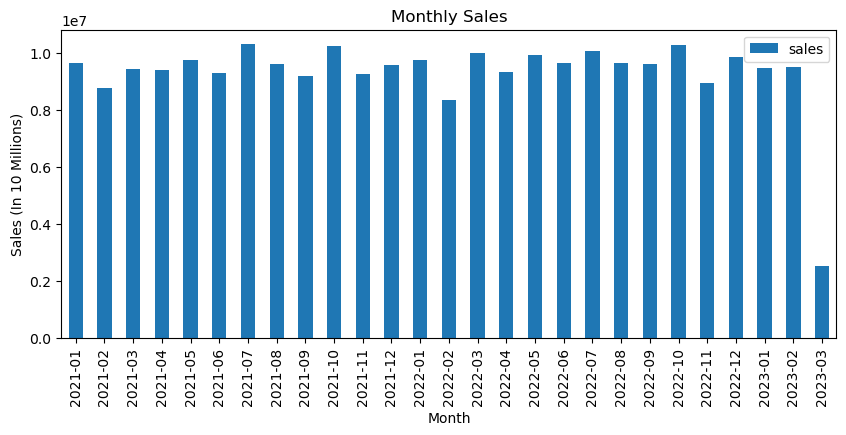

In [117]:
#MEDIUM LEVEL
#QUESTION 3: How is the data distributed across different invoice dates? Are there any seasonal trends or patterns? (Use a graph for this.)
#Note: This code visualizes trends for total sales every MONTH

#Convert datatype of invoice_date to date format
invoice['invoice_date'] = pd.to_datetime(invoice['invoice_date'], format="%d/%m/%Y")

#Extract Year-month from invoice_date
invoice['invoice_month'] = invoice['invoice_date'].dt.to_period('M')

#Filter and group sales by month
seasonal_sales = invoice[['invoice_month','sales']]
seasonal_sales = seasonal_sales.groupby('invoice_month').sum()

#Plot
seasonal_sales.plot(figsize=(10,4),kind="bar", title = "Monthly Sales", xlabel="Month", ylabel="Sales (In 10 Millions)")

#Summary
trends_high = seasonal_sales.nlargest(4,'sales')
trends_low = seasonal_sales.nsmallest(4,'sales')

print('MEDIUM - QUESTION 3')
print("Sales were highest in the following months:")
print(trends_high)
print("")
print("Sales were lowest in the following months:")
print(trends_low)

In [118]:
#HARD LEVEL
#Create a pivot table showing the breakdown of sales across these dimensions, in this order: category, decade age range (e.g., 10-19, 20-29, and so forth).

invoice = pd.read_csv('fct_invoice.csv')
customers_list = pd.read_json('dim_customer.json')

#Add sales column
invoice['sales'] = invoice['quantity'] * invoice['price']

#Setup bins for adding age ranges
bins = [0, 10, 20, 30, 40, 50, 60, 70, 80, 90]
labels = ['Unknown Age', '10-19', '20-29', '30-39', '40-49', '50-59', '60-69', '70-79', '80-89']

#Change NaN to 0 so that they are labelled as "Unknown Age"
customers_list = customers_list.fillna(0)

#Add age ranges
customers_list['age_range'] = pd.cut(customers_list['age'], bins=bins, right=False, labels=labels)

#Merge tables
for_pivot = invoice.merge(right=customers_list[['id', 'age_range']], left_on='customer_id', right_on='id', how='left')

#Make pivot table
table = for_pivot.pivot_table(index='category', columns='age_range', values='sales', aggfunc='sum')

print('HARD - PIVOT TABLE')
table

HARD - PIVOT TABLE


C:\Users\Dree\AppData\Local\Temp\ipykernel_6672\297351855.py:24: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  table = for_pivot.pivot_table(index='category', columns='age_range', values='sales', aggfunc='sum')


age_range,Unknown Age,10-19,20-29,30-39,40-49,50-59,60-69,70-79,80-89
category,,,,,,,,,
Books,334012.05,12801.75,79461.75,84143.10,87203.40,74962.20,80476.80,54827.85,26664.00
Clothing,46003764.40,1927413.84,10250732.80,11354126.96,11215189.92,10321851.76,10660642.08,7769371.28,4493698.00
Cosmetics,2777362.62,109619.36,605915.32,723544.70,665034.96,587780.96,649990.76,419082.62,254531.60
Food & Beverage,345875.59,13582.31,73491.96,87246.86,89553.29,72425.04,80976.09,55050.98,31332.93
Shoes,26468097.17,993281.35,5924878.24,7200839.66,7025590.02,5852857.84,5978893.54,4480269.05,2628744.60
Souvenir,265661.04,12375.15,54943.32,64092.72,66391.80,54943.32,55025.43,38673.81,23718.06
Technology,23865450.00,1129800.00,5261550.00,6159300.00,5954550.00,4435200.00,5471550.00,3638250.00,1946700.00
Toys,1587210.24,60426.24,385100.80,420582.40,390906.88,345067.52,363955.20,273244.16,153932.80
